# Parametrización espectral

***

![voyteklab](./data/voyteklab.png)

***

## Datos simulados y multidimensionales

Tutorial escrito por Quirine Van Engen. Editado por Sydney Smith y Eena Kosik.

<br>

Acabas de revisar cómo funciona el algoritmo de SpecParam sobre una sola señal temporal. Sin embargo, la mayoría de los análisis suelen incluir múltiples electrodos y múltiples condiciones. Por ello, en este notebook simularemos algunos datos que representan múltiples épocas/trials de un solo electrodo y un solo paciente. Después podremos usar `FOOOFGroup` para ejecutar el modelo sobre múltiples espectros de potencia (power spectra) dentro de una sola función o ajuste. Esto acelerará de manera importante tu código y tu análisis.

Sugerimos tener tus datos en el dominio temporal en una estructura 2D, donde cada fila represente un trial y cada columna un punto temporal. Después, los espectros de potencia (power spectra) pueden crearse usando la librería NeuroDSP, que ya has usado antes en este taller. Esto convertirá los datos del dominio temporal al dominio de la frecuencia. Entonces, los espectros de potencia también estarán en una estructura 2D, donde cada fila seguirá representando un trial, pero cada columna representará ahora una frecuencia. Esta estructura 2D puede utilizarse como entrada para el modelo `FOOOFGroup`.

(Sugerimos mantener estructuras de datos separadas para cada condición).

Existen 2 métodos principales de promediado cuando tienes datos con múltiples trials o épocas:
1. Puedes crear los espectros de potencia para cada trial y luego promediar los espectros por condición y por participante. Así, los parámetros que extraiga el modelo ya estarán promediados.
2. Puedes crear los espectros de potencia para cada trial, luego ejecutar el modelo sobre cada uno. Después extraerás los parámetros de cada trial y los promediarás por condición y por participante.

Ambos métodos son válidos; cuál conviene más depende de tu diseño de investigación. Por ejemplo, si tienes EEG continuo en reposo que luego cortas en épocas antes o después de un tratamiento, puedes usar la opción 1. En cambio, la opción 1 no será adecuada si quieres comparar los parámetros antes o después de un evento específico en una tarea. En ese caso te interesará hacer un baselining trial por trial, por lo que la opción 2 será más apropiada.

En este notebook usaremos la opción 2.

Primero, necesitamos importar los módulos necesarios.

In [17]:
# Instalar paquetes necesarios (para Colab)
!pip install neurodsp
!pip install fooof

In [18]:
# Paquetes de Python
import numpy as np
import matplotlib.pyplot as plt

# NeuroDSP
from neurodsp.utils import set_random_seed
from neurodsp.sim import sim_powerlaw, sim_oscillation
from neurodsp.spectral import compute_spectrum
from neurodsp.plts.spectral import plot_power_spectra
from neurodsp.plts.time_series import plot_time_series
from neurodsp.utils import create_times

# SpecParam (FOOOF) 
from fooof import FOOOFGroup
from fooof.analysis import get_band_peak_fg
from fooof.plts.spectra import plot_spectrum


## Comencemos simulando una sola serie temporal

En la celda de abajo simularemos una señal de 3 segundos compuesta por los siguientes componentes:

- una oscilación theta sinusoidal (4 Hz)
- una oscilación alpha sinusoidal (10 Hz)
- un componente de banda ancha aperiódico con un exponente aperiódico de 2.0 μV²/Hz

In [19]:
# Semilla aleatoria para reproducibilidad
set_random_seed(0)

# Configuración de la simulación
fs = 250  # la frecuencia de muestreo de la "grabación" (en Hz)
n_seconds = 3  # la cantidad de segundos por epoch/trial 
times = create_times(n_seconds, fs)  # el eje que contiene el tiempo en segundos (o milisegundos, revisar esto más tarde)

# Configuración para componentes periódicos
theta_freq = 4
alpha_freq = 10
theta_amplitude = 0.2
alpha_amplitude = 0.4

# Configuración para componentes aperiódicos
exponent = -2.0

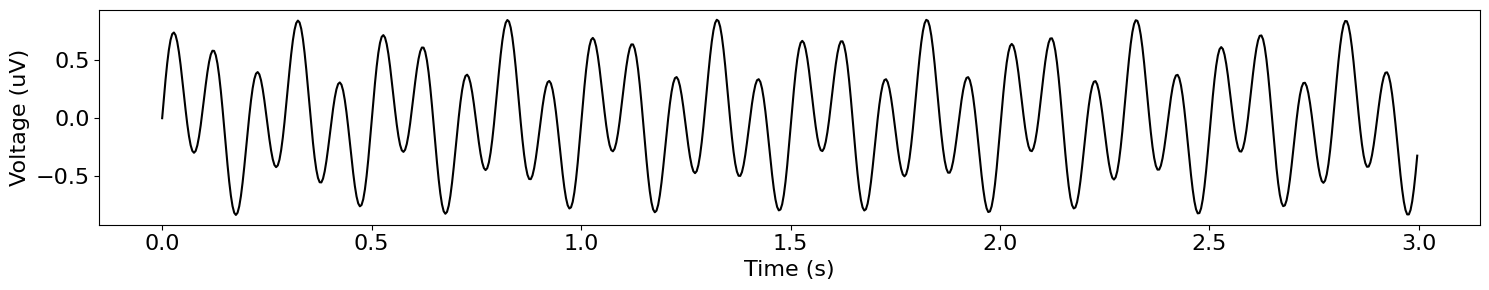

In [20]:
# Simulacion de onda sinoidal
periodic_theta = sim_oscillation(n_seconds=n_seconds, fs=fs, freq=theta_freq, cycle='sine') * theta_amplitude
periodic_alpha = sim_oscillation(n_seconds=n_seconds, fs=fs, freq=alpha_freq, cycle='sine') * alpha_amplitude

periodic = periodic_theta + periodic_alpha

plot_time_series(times, periodic)

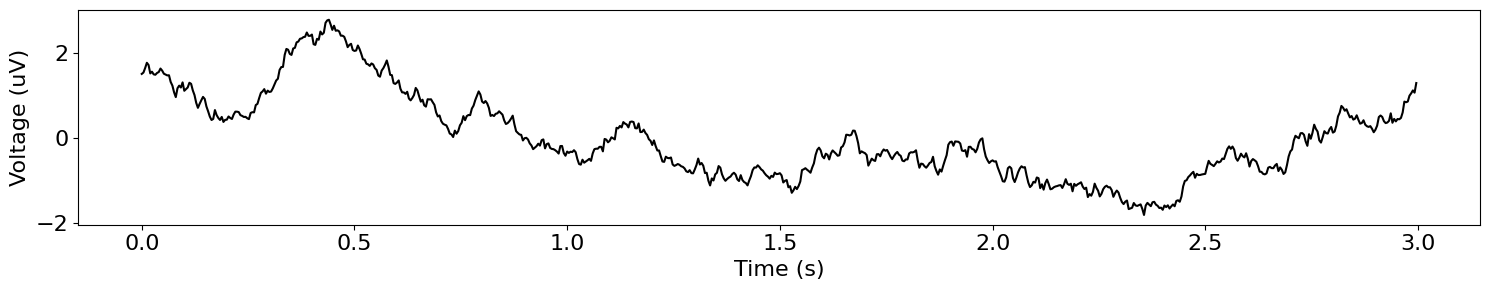

In [21]:
# Parte aperiódica
aperiodic = sim_powerlaw(n_seconds=n_seconds, fs=fs, exponent=exponent)

plot_time_series(times, aperiodic)

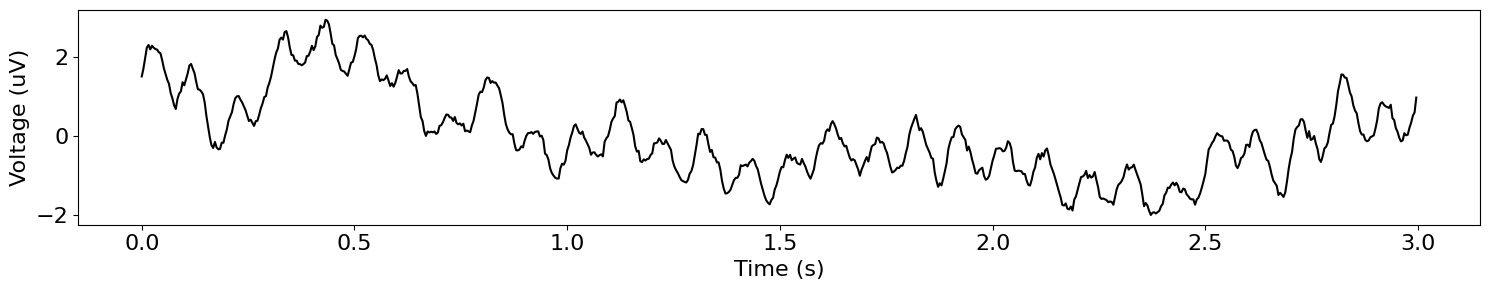

In [22]:
combined = periodic + aperiodic
plot_time_series(times, combined)

## Ahora, creemos múltiples series temporales (30 trials)

Aquí simularemos series temporales que contienen distintas características periódicas y aperiódicas. La primera señal contiene:

- oscilación theta de 0.2 μV² a 5 Hz
- oscilación alpha de 0.4 μV² a 10 Hz
- exponente aperiódico de 2.0 μV²/Hz
    
La segunda señal contiene:
- oscilación theta de 0.4 μV² a 6 Hz
- oscilación alpha de 0.3 μV² a 10 Hz
- exponente aperiódico de 2.0 μV²/Hz

Observa el código de abajo e intenta identificar dónde y cómo se simulan estas señales.

In [23]:
# Semilla aleatoria para reproducibilidad
set_random_seed(0)

# Configuración de la simulación
fs = 250  # la frecuencia de muestreo de la "grabación" (en Hz)
n_seconds = 3  # la cantidad de segundos por epoch/trial 
times = create_times(n_seconds, fs)  # el eje que contiene el tiempo en segundos (o milisegundos, revisar esto más tarde)

# Configuración para condition 1
theta_c1 = 5
alpha_c1 = 10
theta_amp_c1 = 0.2
alpha_amp_c1 = 0.4
exponent_c1 = -2.0

# Configuración para condition 2
theta_c2 = 6
alpha_c2 = 10
theta_amp_c2 = 0.4
alpha_amp_c2 = 0.3
exponent_c2 = -1.5

# Array vacío para guardar los datos simulados (30 simulaciones por condición)
n_timepoints = len(times)
n_trials = 30
condition_1 = np.full((n_trials, n_timepoints), np.nan)
condition_2 = np.full((n_trials, n_timepoints), np.nan)


# Simulacion de los trials para cada condición
for trial in range(0, n_trials):
    # Componentes periódicos
    # for condition 1
    periodic_theta_c1 = sim_oscillation(n_seconds=n_seconds, fs=fs, freq=theta_c1, cycle='sine') * theta_amp_c1
    periodic_alpha_c1 = sim_oscillation(n_seconds=n_seconds, fs=fs, freq=alpha_c1, cycle='sine') * alpha_amp_c1
    periodic_c1 = periodic_theta_c1 + periodic_alpha_c1
    # for condition 2
    periodic_theta_c2 = sim_oscillation(n_seconds=n_seconds, fs=fs, freq=theta_c2, cycle='sine') * theta_amp_c2
    periodic_alpha_c2 = sim_oscillation(n_seconds=n_seconds, fs=fs, freq=alpha_c2, cycle='sine') * alpha_amp_c2
    periodic_c2 = periodic_theta_c2 + periodic_alpha_c2
    
    # Parte aperiódica
    # for condition 1
    aperiodic_c1 = sim_powerlaw(n_seconds=n_seconds, fs=fs, exponent=exponent_c1)
    # for condition 2
    aperiodic_c2 = sim_powerlaw(n_seconds=n_seconds, fs=fs, exponent=exponent_c2)
    
    # Combinar señales periódicas y aperiódicas para cada condición
    condition_1[trial] = periodic_c1 + aperiodic_c1 
    condition_2[trial] = periodic_c2 + aperiodic_c2

#### Grafica una subsección de las series temporales de cada condición para visualizar los datos simulados

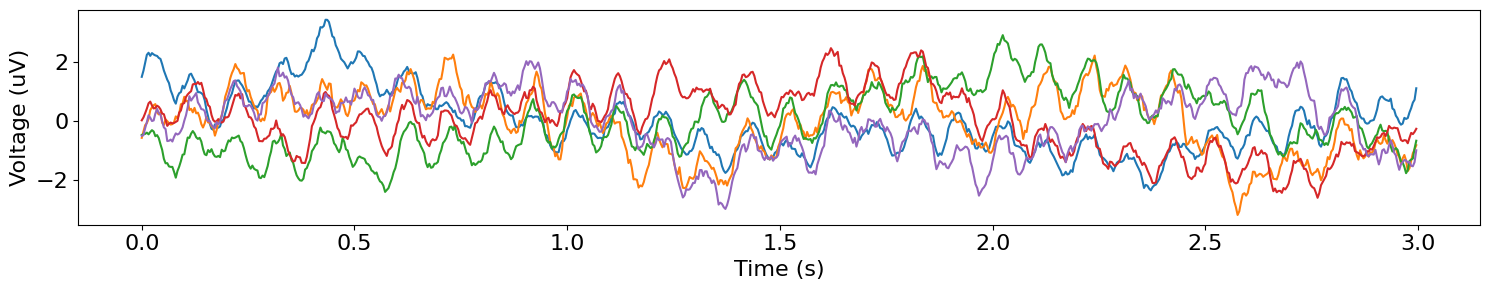

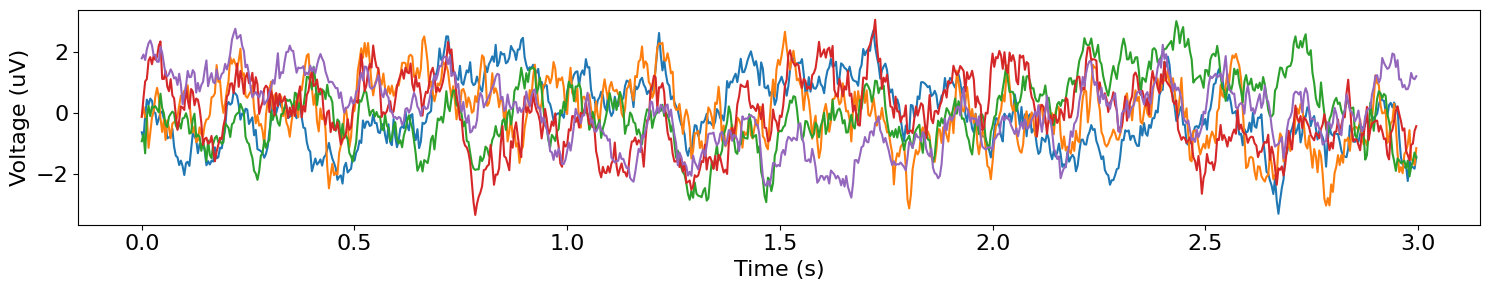

In [24]:
plot_time_series(times, condition_1[:5])  # Matriz transpuesta para que cada trial sea una fila y cada columna un punto en el tiempo
plot_time_series(times, condition_2[:5])

## Crear espectros de potencia

La función `compute_spectrum` puede recibir una estructura 2D y calcula los espectros de potencia para cada fila. Recuerda que cada fila en `condition_1` y `condition_2` representa un trial en el dominio temporal.
Esta función también devuelve un parámetro llamado `freqs`, que corresponde al eje o resolución en frecuencia.

In [25]:
# Espectro de poder para cada condición
freq_c1, psd_c1 = compute_spectrum(condition_1, fs=fs, method='welch')
freq_c2, psd_c2 = compute_spectrum(condition_2, fs=fs, method='welch')

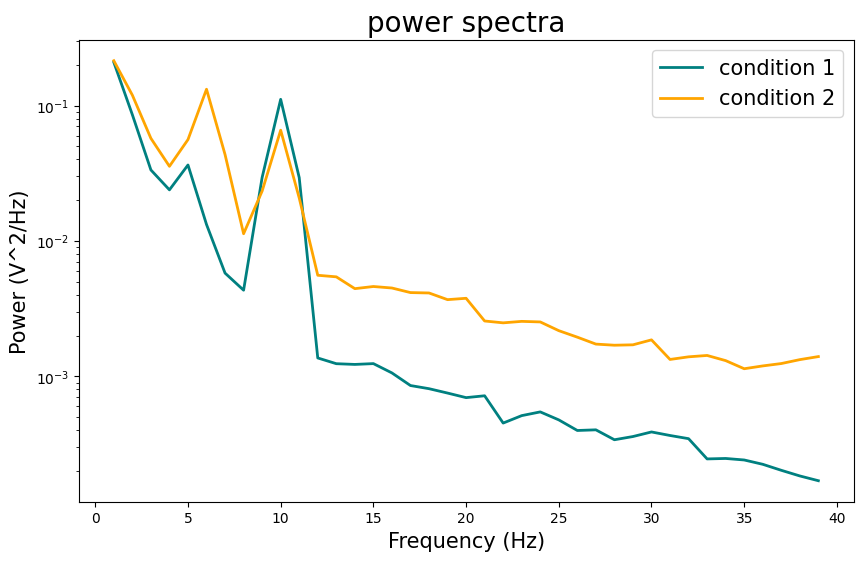

In [26]:
# Espectro de poder promedio para cada condición

plt.figure(figsize=(10,6))

# Lineas
plt.semilogy(freq_c1[1:40], psd_c1.mean(axis=0)[1:40], color='teal', label='condition 1', lw=2)
plt.semilogy(freq_c2[1:40], psd_c2.mean(axis=0)[1:40], color='orange', label='condition 2', lw=2)

# Titulos y leyendas
plt.title('power spectra', size=20)
plt.xlabel('Frequency (Hz)', size=15)
plt.ylabel('Power (V^2/Hz)', size=15)
plt.legend(loc=1, prop={'size': 15})
plt.show()

¿Qué diferencias observas en los espectros de potencia? ¿Se relacionan con tu comprensión de los parámetros que establecimos para simular las condiciones?

## Ajustar el modelo SpecParam (FOOOF)

¡Eso fue bastante fácil para crear los espectros de potencia de cada trial y de ambas condiciones!

Ahora tenemos que crear un modelo para ambas condiciones usando `FOOOFGroup`. Luego ajustaremos el modelo y extraeremos los parámetros que nos interesan: `exponent` y `offset` aperiódicos, así como la `power` ajustada por el componente aperiódico para theta y alpha, la `center frequency` y el `bandwidth`.

También crearemos una configuración del modelo y elegiremos parámetros para reducir tanto el sobreajuste como el subajuste.

In [37]:
# Escalando los datos para evitar problemas con el ajuste de FOOOF

psd_c1_scaled = psd_c1 * 1000
psd_c2_scaled = psd_c2 * 1000

In [38]:
# En este caso, establecemos un límite de ancho de pico para que sea mayor que 2 frecuencias de ancho Y menor que 8 frecuencias de ancho.
# Además, estamos estableciendo un umbral mínimo para la altura del pico para que se considere una oscilación.
specparam_sets = {'peak_width_limits': [2, 8], 'min_peak_height': 0.1}
freq_range = [1, 40]

# Rango de frecuencias que consideramos como oscilaciones theta o alpha
theta_range = [4, 8]
alpha_range = [8, 12]

# Inicializar modelos FOOOFGroup para cada condición
model_c1 = FOOOFGroup(**specparam_sets)
model_c2 = FOOOFGroup(**specparam_sets)

# Entrenar modelos
model_c1.fit(freq_c1, psd_c1_scaled, freq_range=[1, 40])
model_c2.fit(freq_c2, psd_c2_scaled, freq_range=[1, 40])

Running FOOOFGroup across 30 power spectra.
Running FOOOFGroup across 30 power spectra.


/Users/jerjesaguirrechavez/Desktop/Desktop_Current/UCSD/Voytek Lab/spr/spr_env/lib/python3.9/site-packages/scipy/optimize/_lsq/trf.py:234: RuntimeWarning: divide by zero encountered in divide
  Delta = norm(x0 * scale_inv / v**0.5)
/Users/jerjesaguirrechavez/Desktop/Desktop_Current/UCSD/Voytek Lab/spr/spr_env/lib/python3.9/site-packages/scipy/optimize/_lsq/trf.py:363: RuntimeWarning: invalid value encountered in scalar divide
  alpha *= Delta / Delta_new
/Users/jerjesaguirrechavez/Desktop/Desktop_Current/UCSD/Voytek Lab/spr/spr_env/lib/python3.9/site-packages/scipy/optimize/_lsq/common.py:49: RuntimeWarning: invalid value encountered in scalar divide
  t2 = c / q
/Users/jerjesaguirrechavez/Desktop/Desktop_Current/UCSD/Voytek Lab/spr/spr_env/lib/python3.9/site-packages/scipy/optimize/_lsq/trf.py:234: RuntimeWarning: divide by zero encountered in divide
  Delta = norm(x0 * scale_inv / v**0.5)
/Users/jerjesaguirrechavez/Desktop/Desktop_Current/UCSD/Voytek Lab/spr/spr_env/lib/python3.9/sit

BONUS: Si tu computadora o servidor remoto puede realizar procesamiento en paralelo, puedes agregar un argumento extra a `.fit` para acelerar el proceso: `n_jobs=-1`

Esto es posible porque cada espectro de potencia (power spectrum) es independiente de los demás, ya que se deriva de trials distintos.

## Inspeccionar los ajustes del modelo

Usando el comando `plot()`, podemos inspeccionar los ajustes del modelo. SpecParam calcula automáticamente el ajuste del modelo con 2 medidas diferentes: 1) Error y 2) `Rˆ2`.

Esta gráfica también te mostrará todos los ajustes aperiódicos y las frecuencias centrales de los picos que encontró.

Recomendamos mucho graficar siempre estas figuras, porque te dan una primera impresión de qué tan bien el modelo se ajusta a los datos.

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (30,) + inhomogeneous part.

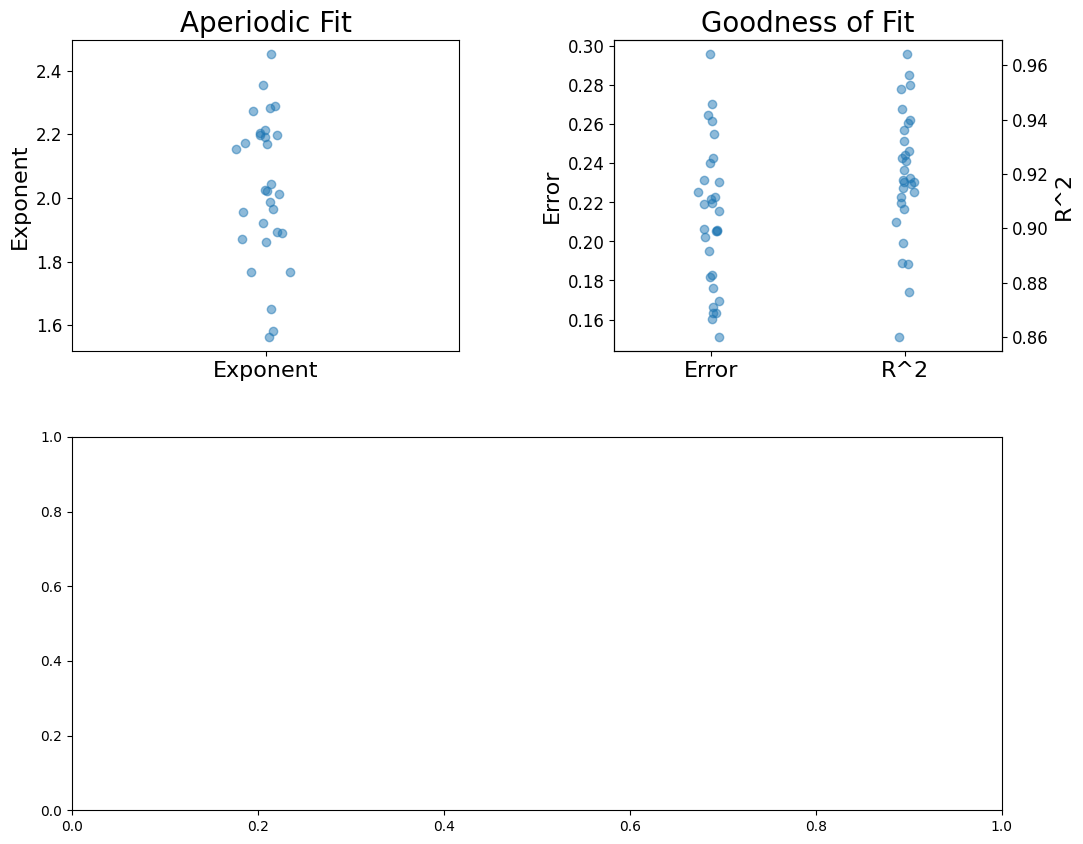

In [39]:
model_c1.plot()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (30,) + inhomogeneous part.

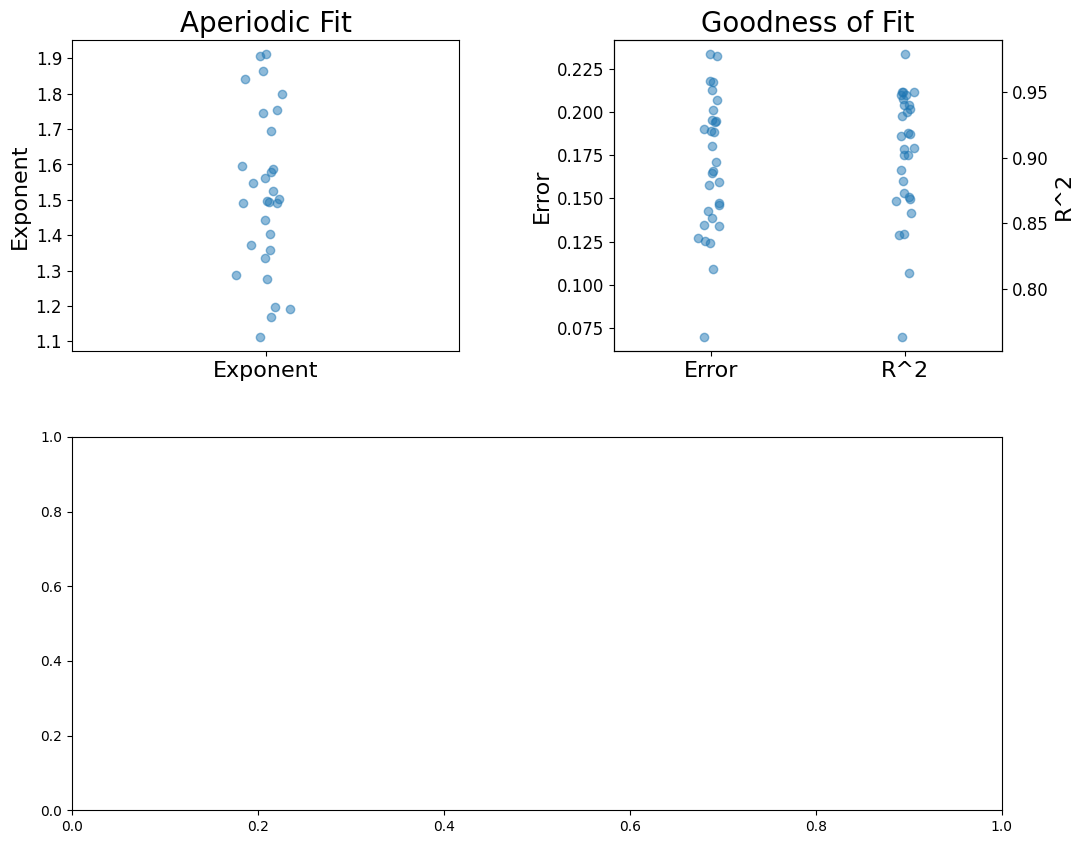

In [14]:
model_c2.plot()

### Extraer y revisar los parámetros

In [40]:
# Extract the aperiodic parameters (exponent and offset)
exp_c1 = model_c1.get_params('aperiodic_params', 'exponent')
exp_c2 = model_c2.get_params('aperiodic_params', 'exponent')
offset_c1 = model_c1.get_params('aperiodic_params', 'offset')
offset_c2 = model_c2.get_params('aperiodic_params', 'offset')

# Extract the periodic paramaters (aperidic adjusted power, band width, center frequency)
theta_c1 = get_band_peak_fg(model_c1, band=theta_range)
theta_c2 = get_band_peak_fg(model_c2, band=theta_range)
alpha_c1 = get_band_peak_fg(model_c1, band=alpha_range)
alpha_c2 = get_band_peak_fg(model_c2, band=alpha_range)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (30,) + inhomogeneous part.

In [41]:
# Let's see what our parameters look like. We have a list of all the exponents for condition 1 here, ordered by trials
exp_c1

array([2.17392682, 1.64958383, 2.01250835, 1.58240361, 2.15470914,
       1.76785826, 1.76554421, 1.95582185, 1.96654549, 1.87117852,
       2.28779935, 2.19855273, 2.19817532, 2.35502748, 2.16861422,
       1.86291353, 2.45139983, 1.56190718, 2.04350846, 2.27272008,
       2.28351275, 1.89031072, 2.02126102, 1.89172909, 2.02436546,
       1.9221909 , 2.19086286, 1.98864504, 2.21488427, 2.20503338])

In [42]:
# Let's look at the theta parameters of condition 1.
# Here we see 3 columns and rows with the same amount as trials. 
# Look up the 'get_band_peak_fg' to see which parameter is which column ---> SPOILER:  [CF, PW, BW]
theta_c1

5

¿Por qué crees que hay `nan`s en este arreglo?

Prueba jugar con los parámetros de simulación de estos datos. También revisa los umbrales de detección de picos cuando se instancia el modelo `FOOOF`. ¿Cómo podrían relacionarse entre sí? Piensa en qué es importante para el ajuste del modelo y si este ajuste es 'fiel' a los datos.

## Por último, grafiquemos algunas diferencias de parámetros entre la condición 1 y la 2

In [43]:
# plotting function

def plot_feature_conditions(feature_c1, feature_c2):
        
    x1 = np.ones(len(feature_c1)) * 0.5
    x2 = np.ones(len(feature_c2)) * 1.5
    plt.scatter(x1+np.random.normal(-0.025,0.025,len(feature_c1)), feature_c1, color='teal', alpha=0.7)
    plt.scatter(x2+np.random.normal(-0.025,0.025,len(feature_c2)), feature_c2, color='orange', alpha=0.7)

    plt.plot([x1-0.1, x1+0.1], [np.nanmean(feature_c1), np.nanmean(feature_c1)], lw=7, c='teal')
    plt.plot([x2-0.1, x2+0.1], [np.nanmean(feature_c2), np.nanmean(feature_c2)], lw=7, c='orange')

    plt.xlim([0, 2])

    plt.xticks([x1[0], x2[0]], ["condition 1", "condition 2"])


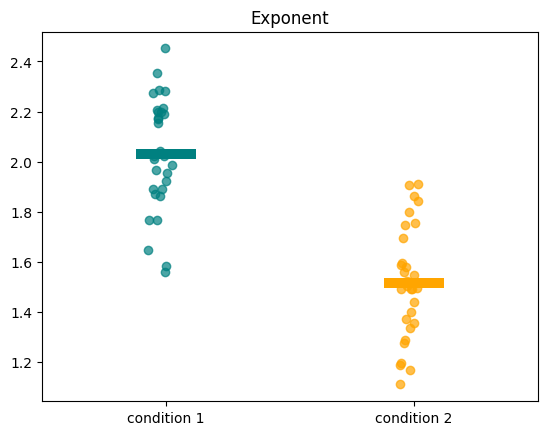

In [44]:
plot_feature_conditions(exp_c1, exp_c2)
plt.title('Exponent');

Podemos ver que `FOOOFGroup` es capaz de capturar la diferencia en el exponente aperiódico de estos datos simulados. La condición 1 fue simulada con `exponent=2` y la condición 2 fue simulada con `exponent=1.5`. 

In [45]:
# To select the theta aperiodic adjusted power, select all rows from column 2
theta_pw_c1 = theta_c1[:,1]
theta_pw_c2 = theta_c2[:,1]

TypeError: 'int' object is not subscriptable

In [46]:
plot_feature_conditions(theta_pw_c1, theta_pw_c2)
plt.title('Aperiodic-adjusted theta power');

NameError: name 'theta_pw_c1' is not defined

In [47]:
# To select the theta center frequency, select all rows from column 1
theta_cf_c1 = theta_c1[:,0]
theta_cf_c2 = theta_c2[:,0]

TypeError: 'int' object is not subscriptable

In [48]:
plot_feature_conditions(theta_cf_c1, theta_cf_c2)
plt.title('Theta center frequency');

NameError: name 'theta_cf_c1' is not defined

¡Puedes graficar más parámetros si quieres!

## Conclusión

En este notebook revisamos cómo implementar el método de parametrización espectral (spectral parameterization) usando datos simulados. Mostramos cómo parametrizar espectros de potencia (power spectra) puede proporcionar una descripción tanto de los componentes aperiódicos como de los periódicos de una señal.

Estos datos, al igual que los que podrías recolectar y analizar, son multidimensionales. La herramienta `FOOOFGroup` nos permite analizar este tipo de datos aplicando el método de parametrización espectral a grandes cantidades de datos al mismo tiempo. Los datos que simulamos aquí son relativamente simples, y las oscilaciones sostenidas de gran amplitud que contienen son bastante diferentes de los datos con los que quizá estés trabajando. Sin embargo, el siguiente notebook probablemente será más interesante, porque usaremos datos intracraneales reales en lugar de datos simulados.